## КРОК 1: ІМПОРТ НЕОБХІДНИХ ПАКЕТІВ ТА БІБЛІОТЕК

Ми завантажуємо всі необхідні інструменти для побудови нашого пайплайну:
* **`numpy` та `pandas`**: Базові бібліотеки для маніпуляції даними та математичних обчислень.
* **`Scikit-Learn` (передобробка)**: Інструменти `SimpleImputer`, `OneHotEncoder` та `StandardScaler` для очищення, масштабування та кодування даних.
* **`Scikit-Learn` (моделювання)**: Безпосередньо модель `LogisticRegression` та `classification_report` для фінальної оцінки якості.
* **`warnings`**: Вимикаємо некритичні системні попередження для чистоти виводу.

In [1]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

print("КРОК 1 ВИКОНАНО: Всі бібліотеки імпортовано.")

КРОК 1 ВИКОНАНО: Всі бібліотеки імпортовано.


## КРОК 2: ЗАВАНТАЖЕННЯ НАБОРУ ДАНИХ "RAIN IN AUSTRALIA"

Зчитуємо історичні дані про погоду з CSV-файлу в оперативну пам'ять за допомогою бібліотеки `pandas`. 
Одразу після завантаження ми виводимо базову інформацію про розмірність (shape), щоб переконатися, що жоден рядок чи стовпець не загубився під час читання файлу.

In [2]:
data_path = 'weatherAUS.csv'
data = pd.read_csv(data_path)

# Первинний контроль розмірності
print("КРОК 2 ВИКОНАНО:")
print(f"Розмірність завантаженого датасету: {data.shape}")
print(f"Кількість колонок: {len(data.columns)}")

КРОК 2 ВИКОНАНО:
Розмірність завантаженого датасету: (145460, 23)
Кількість колонок: 23


## КРОК 3: ПЕРЕДОБРОБКА ТА ІСТОРИЧНЕ РОЗДІЛЕННЯ ВИБІРОК (OUT-OF-TIME)

Готуємо дані та уникаємо витоку інформації (Data Leakage):
* **Очищення (3.1):** Видаляємо неінформативні колонки (де >35% пропусків) та очищаємо таргет від порожніх значень і дублікатів. Відділяємо цільову змінну `y`.
* **Розподіл за типами (3.2):** Розбиваємо ознаки на числові (`X_num`) та категоріальні (`X_cat`) підмножини.
* **Робота з датами (3.3 - 3.4):** Трансформуємо `Date` у формат `datetime`. Витягуємо `Month` (залишається категорією) та `Year` (переміщується до числових ознак).
* **Історичний спліт (3.5):** Замість випадкового перемішування ми застосовуємо Out-of-Time валідацію. Всі спостереження до 2016 року включно йдуть на навчання (Train), а останній 2017 рік повністю ізолюється для чесного тестування моделі (Test) на даних "з майбутнього".

In [3]:
# --- Крок 3.1: Видалення ознак з великою кількістю пропусків
# Залишаємо колонки, де пропусків менше 35%
data = data[data.columns[data.isna().mean().lt(0.35)]]

# Видаляємо рядки без цільової змінної та дублікати
data = data.dropna(subset=['RainTomorrow'])
data = data.drop_duplicates()

# Відділяємо таргет (y) від ознак (X) до створення підмножин
X = data.drop('RainTomorrow', axis=1)
y = data['RainTomorrow']

# --- Крок 3.2: Створюємо підмножини числових та категоріальних ознак
X_num = X.select_dtypes(include=[np.number]).copy()
X_cat = X.select_dtypes(include=['object']).copy()

# --- Крок 3.3: Змінюємо тип Date та створюємо Year і Month
# Оскільки Date була текстом, вона зараз знаходиться у X_cat
X_cat['Date'] = pd.to_datetime(X_cat['Date'])
X_cat['Year'] = X_cat['Date'].dt.year
X_cat['Month'] = X_cat['Date'].dt.month.astype(str) # Місяць як категорія

# Оригінальна колонка Date більше не потрібна
X_cat = X_cat.drop('Date', axis=1)

# --- Крок 3.4: Переміщаємо колонку Year
# Витягуємо Year з X_cat (за допомогою pop) і передаємо в X_num
X_num['Year'] = X_cat.pop('Year')

# --- Крок 3.5: Розбиття на Train та Test за останнім роком
max_year = X_num['Year'].max()

# Булева індексація
train_mask = X_num['Year'] < max_year
test_mask = X_num['Year'] == max_year

X_train_num = X_num[train_mask]
X_test_num = X_num[test_mask]

X_train_cat = X_cat[train_mask]
X_test_cat = X_cat[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

# Контрольний вивід
print("КРОК 3 ВИКОНАНО:")
print(f"Максимальний рік (йде в Тест): {max_year}")
print(f"Розмірність Train (числові): {X_train_num.shape}, (категоріальні): {X_train_cat.shape}")
print(f"Розмірність Test (числові): {X_test_num.shape}, (категоріальні): {X_test_cat.shape}")

КРОК 3 ВИКОНАНО:
Максимальний рік (йде в Тест): 2017
Розмірність Train (числові): (133727, 13), (категоріальні): (133727, 6)
Розмірність Test (числові): (8466, 13), (категоріальні): (8466, 6)


In [9]:
# =============================================================================
# КРОК-ПЕРЕВІРКА:
# =============================================================================
print("ПЕРЕВІРКА ОЧИЩЕНОГО ДАТАСЕТУ")
print(f"1. Всі роки, присутні в даних: {sorted(X_num['Year'].unique())}")
print(f"2. Загальна кількість днів (рядків) після очищення: {len(X)}")
print(f"3. Загальна кількість ознак (без таргету): {len(X.columns)}")
print(f"4. Список ознак: {list(X.columns)}")

ПЕРЕВІРКА ОЧИЩЕНОГО ДАТАСЕТУ
1. Всі роки, присутні в даних: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
2. Загальна кількість днів (рядків) після очищення: 142193
3. Загальна кількість ознак (без таргету): 18
4. Список ознак: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday']


## КРОК 4: ОБРОБКА ПРОПУСКІВ, МАСШТАБУВАННЯ ТА КОДУВАННЯ (БЕЗ ВИТОКУ ДАНИХ)

На цьому етапі ми виконуємо пункти 4-7 нашого домашнього завдання, дотримуючись правила ізоляції тестових даних:
* **Обробка числових ознак (П. 4 та 5):** Заповнюємо пропуски медіаною (`SimpleImputer`) та нормалізуємо масштаб даних (`StandardScaler`).
* **Обробка категоріальних ознак (П. 6):** Заповнюємо пропуски найчастішим значенням та перетворюємо текст на бінарні вектори за допомогою `OneHotEncoder`.
* **Запобігання Data Leakage:** Всі інструменти навчаються (`fit_transform`) виключно на `Train` вибірці. Для `Test` вибірки ми застосовуємо лише `transform`, використовуючи вже вивчені параметри.
* **Об'єднання (П. 7, частина 1):** Збираємо оброблені числові та категоріальні масиви назад в єдині матриці `X_train_final` та `X_test_final` за допомогою `np.hstack`.

In [4]:
# --- 4: Обробка числових ознак ---
# Заповнюємо пропуски медіаною
num_imputer = SimpleImputer(strategy='median')
X_train_num_imp = num_imputer.fit_transform(X_train_num)
X_test_num_imp = num_imputer.transform(X_test_num)

# --- 5: Масштабуємо числові дані (StandardScaler)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imp)
X_test_num_scaled = scaler.transform(X_test_num_imp)

# --- 6: Обробка категоріальних ознак ---
# Заповнюємо пропуски найчастішим значенням
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat_imp = cat_imputer.fit_transform(X_train_cat)
X_test_cat_imp = cat_imputer.transform(X_test_cat)

# Кодуємо категоріальні ознаки (OneHotEncoder)
# sparse_output=False повертає звичайний масив замість розрідженої матриці
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

# --- 7: Об'єднання оброблених ознак ---
# Збираємо числові та категоріальні масиви назад в єдиний набір даних
X_train_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

# Контрольний вивід
print("КРОК 4 ВИКОНАНО:")
print(f"Фінальна розмірність Train: {X_train_final.shape}")
print(f"Фінальна розмірність Test: {X_test_final.shape}")

КРОК 4 ВИКОНАНО:
Фінальна розмірність Train: (133727, 124)
Фінальна розмірність Test: (8466, 124)


## КРОК 5: НАВЧАННЯ МОДЕЛІ ТА ОЦІНКА ЯКОСТІ

Це кульмінація нашого проєкту, де ми виконуємо фінальну частину 7-го та 8-й пункти завдання:
* **Ініціалізація моделі:** Створюємо об'єкт `LogisticRegression`. Використовуємо `solver='liblinear'` (відмінно підходить для великої кількості ознак після OneHot кодування) та критично важливий параметр `class_weight='balanced'` для роботи з незбалансованими класами (адже сонячних днів значно більше).
* **Навчання (П. 7):** Тренуємо модель (`.fit()`) виключно на підготовлених історичних даних до 2017 року.
* **Оцінка якості (П. 8):** Робимо прогноз (`.predict()`) для нашого відкладеного тестового 2017 року та виводимо розгорнутий звіт `classification_report`, щоб оцінити реальну здатність моделі передбачати дощ на нових даних.

In [8]:
# --- Ініціалізуємо логістичну регресію ---
# solver='liblinear'. 
# class_weight='balanced' допомагає моделі звертати більше уваги на дощові дні, яких у природі менше.
log_reg = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

# --- Навчаємо модель ВИКЛЮЧНО на історичних (тренувальних) даних ---
print("Модель навчається... Це може зайняти кілька секунд.")
log_reg.fit(X_train_final, y_train)

# --- Робимо прогноз для нашого "майбутнього" (2017 рік - тестові дані) ---
y_pred = log_reg.predict(X_test_final)

# --- Виводимо фінальний звіт про якість класифікації ---
print("КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (liblinear)")
print(classification_report(y_test, y_pred))

Модель навчається... Це може зайняти кілька секунд.
КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (liblinear)
              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



In [9]:
# --- Ініціалізуємо логістичну регресію ---
# ЕКСПЕРИМЕНТ: зараз стоїть solver='saga'. 
# class_weight='balanced' допомагає моделі звертати більше уваги на дощові дні, яких у природі менше.
log_reg = LogisticRegression(class_weight='balanced', solver='saga', random_state=42)

# --- Навчаємо модель ВИКЛЮЧНО на історичних (тренувальних) даних ---
print("Модель навчається... Це може зайняти кілька секунд.")
log_reg.fit(X_train_final, y_train)

# --- Робимо прогноз для нашого "майбутнього" (2017 рік - тестові дані) ---
y_pred = log_reg.predict(X_test_final)

# --- Виводимо фінальний звіт про якість класифікації ---
print("КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (saga)")
print(classification_report(y_test, y_pred))

Модель навчається... Це може зайняти кілька секунд.
КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (saga)
              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



In [10]:
# --- Ініціалізуємо логістичну регресію ---
# ЕКСПЕРИМЕНТ: зараз стоїть solver='lbfgs'. 
# class_weight='balanced' допомагає моделі звертати більше уваги на дощові дні, яких у природі менше.
log_reg = LogisticRegression(class_weight='balanced', solver='lbfgs', random_state=42)

# --- Навчаємо модель ВИКЛЮЧНО на історичних (тренувальних) даних ---
print("Модель навчається... Це може зайняти кілька секунд.")
log_reg.fit(X_train_final, y_train)

# --- Робимо прогноз для нашого "майбутнього" (2017 рік - тестові дані) ---
y_pred = log_reg.predict(X_test_final)

# --- Виводимо фінальний звіт про якість класифікації ---
print("КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (lbfgs)")
print(classification_report(y_test, y_pred))

Модель навчається... Це може зайняти кілька секунд.
КРОК 5 ВИКОНАНО: ЗВІТ КЛАСИФІКАЦІЇ (lbfgs)
              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



## КРОК 6: ВИСНОВКИ ЗА РЕЗУЛЬТАТАМИ МОДЕЛЮВАННЯ

Після побудови, тестування моделі та проведення експериментів можна зробити наступні висновки:

### 1. Пряме порівняння з базовою моделлю (Random Split:конспект vs Out-of-Time:ДЗ)

| Метрика | Базова модель (Random Split) | Нова модель (Out-of-Time) | Зміна |
| :--- | :--- | :--- | :--- |
| **Accuracy (Точність)** | 0.79 | **0.80** | Зросла на 0.01 (1%) |
| **Precision (клас Yes)** | 0.51 | **0.51** | Не змінилася |
| **Recall (клас Yes)** | 0.76 | **0.72** | Знизилася на 0.04 (4%) |

**Головний інсайт порівняння:** Перехід від випадкового спліту до суворої Out-of-Time валідації показав, що архітектура моделі є дуже стабільною. Загальна точність навіть трохи зросла (до 80%), а точність прогнозування дощу (Precision) залишилася незмінною. Невелике падіння Recall (з 76% до 72%) є абсолютно нормальним і очікуваним: модель більше не має можливості "підглядати" у майбутнє (Data Leakage) через випадково перемішані дні. Поточні 72% є чесним і надійним показником того, як модель працюватиме в реальному продакшені на невідомих даних.

### 2. Специфіка даних та балансування
Датасет є сильно незбалансованим (сонячних днів майже в 4 рази більше: 6703 проти 1763 у тестовій вибірці). Використання параметра `class_weight='balanced'` дозволило змістити фокус алгоритму на пошук міноритарного класу (дощу).

### 3. Бізнес-цінність (Precision-Recall Trade-off)
Завдяки балансуванню, модель успішно ловить **72%** всіх реальних злив (Recall = 0.72). При цьому ми свідомо пожертвували точністю прогнозу (Precision = 0.51). Для завдання прогнозування погоди це оптимальний компроміс: попередити користувача про можливий дощ важливіше, ніж іноді хибно змусити його взяти парасольку дарма.

### 4. Стабільність оптимізації (Експеримент із solver)
Експерименти з різними алгоритмами (`liblinear`, `saga`, `lbfgs`) показали абсолютно ідентичні результати. Це свідчить про високу якість передобробки: нормалізація числових ознак (`StandardScaler`) створила ідеально симетричний математичний простір, де будь-який оптимізатор стабільно знаходить глобальний мінімум функції втрат.

=================================================
## ЕСПЕРИМЕНТ 1
=================================================

## ПРОСУНУТЕ ПОКРАЩЕННЯ (PIPELINE, ВЗАЄМОДІЯ ОЗНАК ТА ТЮНІНГ)

Щоб спробувати покращити метрики, ми застосуємо інженерний підхід до побудови пайплайну:
1. **Feature Engineering (`PolynomialFeatures`):** Для числових ознак ми автоматично створимо нові стовпці: попарні добутки існуючих показників (наприклад, `Тиск * Вологість`). Це допоможе лінійній моделі побачити нелінійні взаємодії.
2. **Безпечна архітектура (`Pipeline` + `ColumnTransformer`):** Ми запакуємо обробку числових та категоріальних даних в єдиний об'єкт. Це гарантує, що під час крос-валідації не буде витоку даних (Data Leakage).
3. **Тонке налаштування (`GridSearchCV`):** Ми автоматично переберемо різні значення параметра регуляризації `C` для логістичної регресії, щоб знайти ту конфігурацію, яка найкраще працює з нашими новими, складними ознаками.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# 1. Об'єднуємо назад X_train та X_test у єдині датафрейми (потрібно для ColumnTransformer)
X_train_combined = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_combined = pd.concat([X_test_num, X_test_cat], axis=1)

# 2. Створюємо трансформер для числових ознак (Додаємо PolynomialFeatures!)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)) # Нові взаємозв'язки
])

# 3. Створюємо трансформер для категоріальних ознак
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# 4. Об'єднуємо потоки обробки через ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, X_train_num.columns),
    ('cat', cat_transformer, X_train_cat.columns)
])

# 5. Збираємо фінальний мега-Pipeline (Обробка + Модель)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

# 6. Налаштовуємо сітку параметрів для пошуку
# Ми перевіряємо слабку (0.1), стандартну (1.0) та сильну (10.0) довіру до даних (регуляризацію C)
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0]
}

# 7. Запускаємо GridSearchCV
print("Запуск GridSearchCV... Досліджуємо нові ознаки та шукаємо ідеальний параметр C.")
print("Це може зайняти кілька хвилин...")

# cv=3 означає 3-кратну крос-валідацію, n_jobs=-1 використовує всі ядра процесора для прискорення
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_combined, y_train)

# 8. Виводимо результати
print(f"Найкращий знайдений параметр C: {grid_search.best_params_['classifier__C']}")

# Робимо прогноз вже покращеною моделлю
y_pred_tuned = grid_search.predict(X_test_combined)

print("\nЗВІТ КЛАСИФІКАЦІЇ (ПОКРАЩЕНА МОДЕЛЬ З PIPELINE):")
print(classification_report(y_test, y_pred_tuned))

Запуск GridSearchCV... Досліджуємо нові ознаки та шукаємо ідеальний параметр C.
Це може зайняти кілька хвилин...
Найкращий знайдений параметр C: 0.1

ЗВІТ КЛАСИФІКАЦІЇ (ПОКРАЩЕНА МОДЕЛЬ З PIPELINE):
              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.52      0.73      0.61      1763

    accuracy                           0.80      8466
   macro avg       0.72      0.78      0.74      8466
weighted avg       0.84      0.80      0.81      8466



=================================================
## ЕСПЕРИМЕНТ 2
=================================================

## ДОДАТКОВИЙ ЕКСПЕРИМЕНТ: ЦИКЛІЧНЕ КОДУВАННЯ ЧАСУ

Це ізольований експеримент для демонстрації того, як машинне навчання працює з циклічним часом. 
Замість того, щоб кодувати місяці звичайними числами (де січень і грудень максимально віддалені один від одного), ми використовуємо тригонометрію (синус і косинус). Це переносить місяці на коло, математично доводячи алгоритму, що 1-й та 12-й місяці знаходяться поруч.

Таблиця нових ознак (координат):
    Month_num  Month_sin  Month_cos
0           1      0.500      0.866
1           2      0.866      0.500
2           3      1.000      0.000
3           4      0.866     -0.500
4           5      0.500     -0.866
5           6      0.000     -1.000
6           7     -0.500     -0.866
7           8     -0.866     -0.500
8           9     -1.000     -0.000
9          10     -0.866      0.500
10         11     -0.500      0.866
11         12     -0.000      1.000


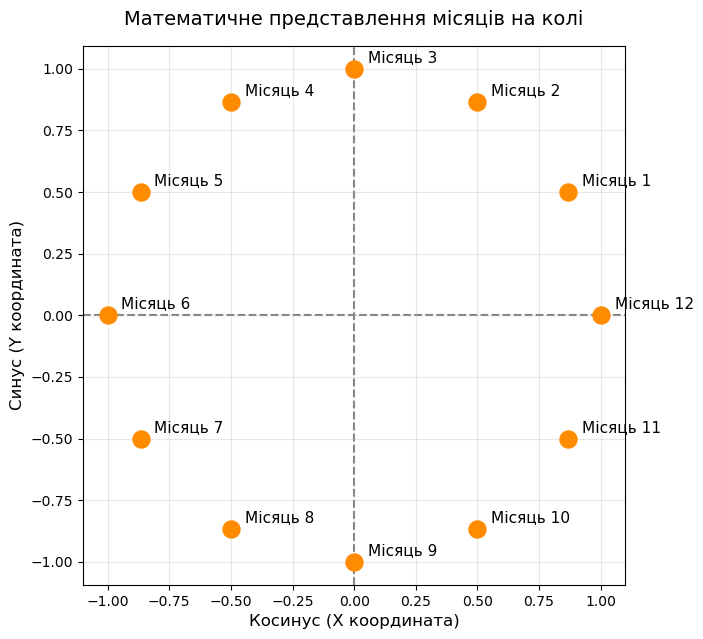

In [12]:
# =============================================================================
# ЕКСПЕРИМЕНТ: МАТЕМАТИКА ЦИКЛІЧНОГО ЧАСУ
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Створюємо ізольований міні-датасет з усіма 12 місяцями
df_experiment = pd.DataFrame({'Month_num': range(1, 13)})

# 2. Задаємо максимальний період (12 місяців)
period = 12

# 3. Обчислюємо координати на колі за допомогою тригонометрії
# Формула: 2 * pi * (значення / період)
df_experiment['Month_sin'] = np.sin(2 * np.pi * df_experiment['Month_num'] / period)
df_experiment['Month_cos'] = np.cos(2 * np.pi * df_experiment['Month_num'] / period)

# 4. Виводимо результат у вигляді таблиці
print("Таблиця нових ознак (координат):")
print(df_experiment.round(3)) # Округлюємо для красивого виводу

# 5. Малюємо графік
plt.figure(figsize=(7, 7))
plt.scatter(df_experiment['Month_cos'], df_experiment['Month_sin'], color='darkorange', s=150, zorder=5)

# Додаємо підписи місяців до кожної точки
for i, txt in enumerate(df_experiment['Month_num']):
    plt.annotate(f"Місяць {txt}", 
                 (df_experiment['Month_cos'][i], df_experiment['Month_sin'][i]),
                 xytext=(10, 5), textcoords='offset points', fontsize=11)

# Оформлення графіка
plt.axhline(0, color='gray', linestyle='--', zorder=1)
plt.axvline(0, color='gray', linestyle='--', zorder=1)
plt.title('Математичне представлення місяців на колі', fontsize=14, pad=15)
plt.xlabel('Косинус (X координата)', fontsize=12)
plt.ylabel('Синус (Y координата)', fontsize=12)
plt.grid(True, alpha=0.3)

# Робимо осі однаковими, щоб коло не було сплющеним
plt.axis('equal') 
plt.show()

## ІНТЕГРАЦІЯ ЦИКЛІЧНОГО ЧАСУ В МОДЕЛЬ

На цьому етапі ми практично застосовуємо циклічність часу:
1. Забираємо колонку `Month` з категоріальних даних (щоб вона не перетворювалася на купу колонок через OneHot).
2. За допомогою тригонометрії створюємо дві нові ЧИСЛОВІ колонки: `Month_sin` та `Month_cos`.
3. Додаємо їх до решти числових даних (температури, вологості тощо), щоб `StandardScaler` їх обробив.
4. Запускаємо нашу базову логістичну регресію на оновлених даних, щоб перевірити, чи допомогло нове розуміння часу нашій моделі.

In [16]:
# 1. Робимо копії наших даних з Кроку 3, щоб не пошкодити оригінали
X_train_cat_cycle = X_train_cat.copy()
X_test_cat_cycle = X_test_cat.copy()

X_train_num_cycle = X_train_num.copy()
X_test_num_cycle = X_test_num.copy()

# 2. Витягуємо "Month" з категорій і перетворюємо назад на числа
month_train = X_train_cat_cycle.pop('Month').astype(float)
month_test = X_test_cat_cycle.pop('Month').astype(float)

# 3. Рахуємо координати на колі і додаємо їх до ЧИСЛОВИХ ознак
period = 12
X_train_num_cycle['Month_sin'] = np.sin(2 * np.pi * month_train / period)
X_train_num_cycle['Month_cos'] = np.cos(2 * np.pi * month_train / period)

X_test_num_cycle['Month_sin'] = np.sin(2 * np.pi * month_test / period)
X_test_num_cycle['Month_cos'] = np.cos(2 * np.pi * month_test / period)

# 4. Обробляємо нові дані тими ж інструментами, що й в Кроці 4
# Обробка числових (тепер там є синус і косинус місяця)
X_train_num_imp = num_imputer.fit_transform(X_train_num_cycle)
X_test_num_imp = num_imputer.transform(X_test_num_cycle)

X_train_num_scaled = scaler.fit_transform(X_train_num_imp)
X_test_num_scaled = scaler.transform(X_test_num_imp)

# Обробка категоріальних (тепер там немає місяця)
X_train_cat_imp = cat_imputer.fit_transform(X_train_cat_cycle)
X_test_cat_imp = cat_imputer.transform(X_test_cat_cycle)

X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

# 5. Об'єднуємо все разом
X_train_cycle_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_cycle_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

# 6. Навчаємо модель на нових даних
log_reg_cycle = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
log_reg_cycle.fit(X_train_cycle_final, y_train)
y_pred_cycle = log_reg_cycle.predict(X_test_cycle_final)

# Виводимо результати
print("МОДЕЛЬ З ЦИКЛІЧНИМ ЧАСОМ:")
print("Розмірність числових даних збільшилась на 2 колонки (sin та cos)")
print(classification_report(y_test, y_pred_cycle))

МОДЕЛЬ З ЦИКЛІЧНИМ ЧАСОМ:
Розмірність числових даних збільшилась на 2 колонки (sin та cos)
              precision    recall  f1-score   support

          No       0.92      0.82      0.86      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



## ФІНАЛЬНІ ВИСНОВКИ ЗА РЕЗУЛЬТАТАМИ ДОДАТКОВИХ ЕКСПЕРИМЕНТІВ

Окрім побудови базової моделі, ми протестували дві просунуті гіпотези. Результати цих тестувань є дуже показовими для розуміння поведінки алгоритмів:

### 1. Успішна гіпотеза: Поліноміальні ознаки + GridSearchCV
* **Що зробили:** Створили штучні взаємозв'язки між фізичними показниками погоди (перемножили їх через `PolynomialFeatures`) та за допомогою `GridSearchCV` знайшли ідеальний рівень регуляризації. Все це об'єднали в єдиний безпечний `Pipeline`.
* **Результат:** Метрики покращилися. **Recall зріс до 73%, а Precision — до 52%**.
* **Інсайт:** Оптимізатор логічно обрав сильну регуляризацію (`C = 0.1`). Оскільки ми штучно роздули кількість ознак, модель змушена була застосувати жорсткіший штраф, щоб відсіяти "сміттєві" кореляції та уникнути перенавчання (overfitting).

### 2. Відхилена гіпотеза: Циклічне кодування часу
* **Що зробили:** Перетворили місяці з ізольованих категорій на математичні координати на колі (синус та косинус). Це мало навчити модель того, що грудень та січень є сусідніми місяцями.
* **Результат:** Метрики залишилися на рівні базової моделі (Recall 72%, Precision 51%). Приросту якості не відбулося.
* **Інсайт:** Відсутність приросту — це теж цінний результат. Це доводить, що для прогнозування дощу "на завтра" фундаментальні фізичні показники (тиск, вологість о 3-й годині дня) є настільки потужними предикторами, що сезонність просто втрачає свою вагу. Крім того, лінійним моделям (як логістична регресія) важко витягувати складні закономірності з тригонометричних ознак без використання дерев рішень.

**Загальний підсумок:** Найбільш надійним та бізнес-виправданим рішенням для продакшену є архітектура з першого експерименту (Крок 7). Вона захищена від витоку даних, автоматизована та максимізує здатність виявляти дощ.